# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [4]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [5]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 4. Load the Data


In [6]:
def load_har_data(root_dir="UCI HAR Dataset"):
    root_path = pathlib.Path(root_dir)

    X_train = np.loadtxt(
        root_path / "train" / "X_train.txt",
        dtype=np.float32
    )
    y_train = np.loadtxt(
        root_path / "train" / "y_train.txt",
        dtype=np.int64
    ) - 1

    X_test = np.loadtxt(
        root_path / "test" / "X_test.txt",
        dtype=np.float32
    )
    y_test = np.loadtxt(
        root_path / "test" / "y_test.txt",
        dtype=np.int64
    ) - 1

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Number of features:", num_features)
print("Number of classes:", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)
Number of features: 561
Number of classes: 6


## 5. Quick Inspection


In [7]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

class_counts = np.bincount(y_train, minlength=num_classes)

class_summary_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": class_names,
    "Training Samples": class_counts
})

class_summary_df


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [23]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,), name="features"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="uci_har_baseline_dnn")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "uci_har_baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 2s 10ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 9ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 9ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [=

### Training Curves


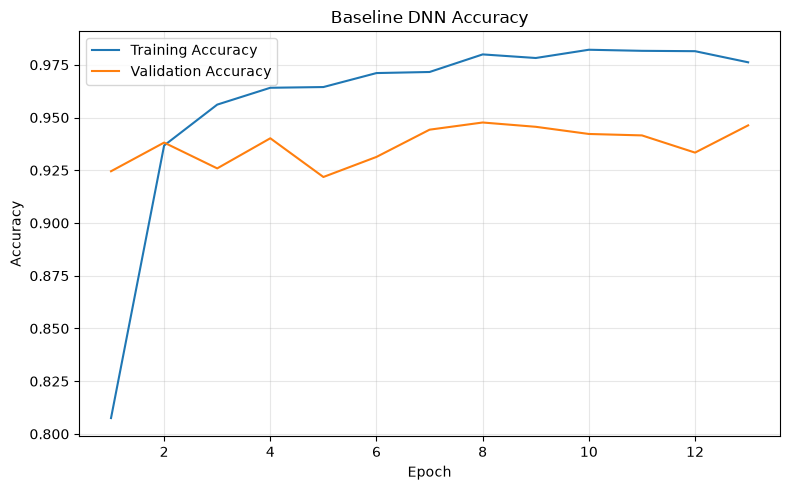

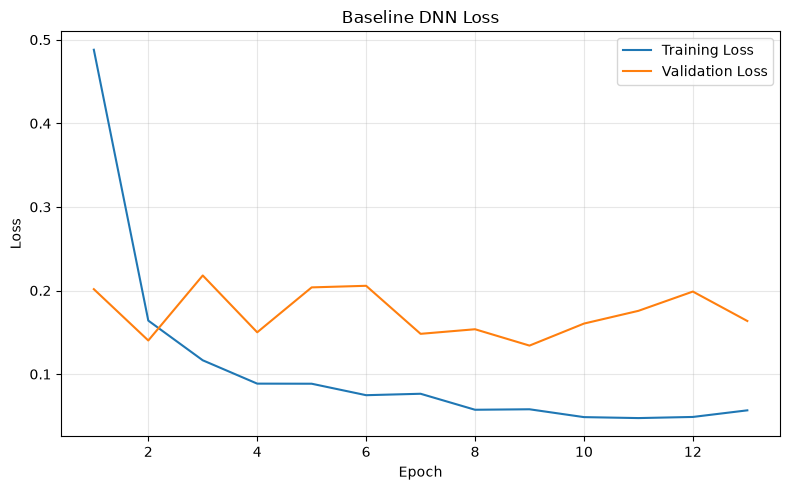

In [10]:
epoch_numbers = range(
    1,
    len(history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))
plt.plot(
    epoch_numbers,
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    epoch_numbers,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline DNN Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epoch_numbers,
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    epoch_numbers,
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline DNN Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


Baseline Keras test accuracy: 0.9220

Classification report:
                    precision    recall  f1-score   support

           WALKING     0.9453    0.9415    0.9434       496
  WALKING_UPSTAIRS     0.9505    0.8960    0.9224       471
WALKING_DOWNSTAIRS     0.8911    0.9548    0.9218       420
           SITTING     0.9752    0.8004    0.8792       491
          STANDING     0.8106    0.9812    0.8878       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9220      2947
         macro avg     0.9288    0.9212    0.9218      2947
      weighted avg     0.9290    0.9220    0.9222      2947



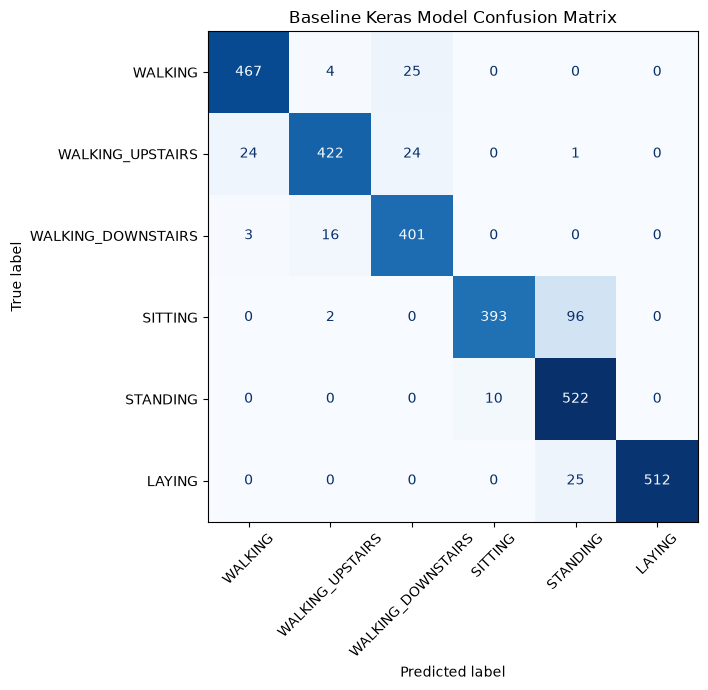

In [11]:
baseline_probabilities = baseline_model.predict(
    X_test,
    verbose=0
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    f"Baseline Keras test accuracy: "
    f"{baseline_test_accuracy:.4f}"
)

print("\nClassification report:")

print(classification_report(
    y_test,
    baseline_predictions,
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=4,
    zero_division=0
))

baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_predictions,
    labels=np.arange(num_classes)
)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=class_names
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title(
    "Baseline Keras Model Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [12]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)

    return os.path.getsize(filename) / 1024.0


def representative_dataset_gen():
    rng = np.random.default_rng(SEED)

    sample_count = min(
        300,
        len(X_train)
    )

    representative_indices = rng.choice(
        len(X_train),
        size=sample_count,
        replace=False
    )

    for index in representative_indices:
        sample = X_train[
            index:index + 1
        ].astype(np.float32)

        yield [sample]


def evaluate_tflite_model(
    tflite_model,
    X,
    y_true
):
    interpreter = tf.lite.Interpreter(
        model_content=tflite_model
    )

    interpreter.allocate_tensors()

    input_details = (
        interpreter.get_input_details()[0]
    )

    output_details = (
        interpreter.get_output_details()[0]
    )

    input_scale, input_zero_point = (
        input_details["quantization"]
    )

    output_scale, output_zero_point = (
        output_details["quantization"]
    )

    y_pred = []

    for i in range(len(X)):
        x = X[i:i + 1].astype(np.float32)

        if input_details["dtype"] in (
            np.int8,
            np.uint8
        ):
            if input_scale == 0:
                raise ValueError(
                    "Quantized input tensor has "
                    "an invalid scale of 0."
                )

            x = np.round(
                x / input_scale +
                input_zero_point
            )

            dtype_limits = np.iinfo(
                input_details["dtype"]
            )

            x = np.clip(
                x,
                dtype_limits.min,
                dtype_limits.max
            )

            x = x.astype(
                input_details["dtype"]
            )

        else:
            x = x.astype(
                input_details["dtype"]
            )

        interpreter.set_tensor(
            input_details["index"],
            x
        )

        interpreter.invoke()

        output = interpreter.get_tensor(
            output_details["index"]
        )

        if output_details["dtype"] in (
            np.int8,
            np.uint8
        ):
            if output_scale == 0:
                raise ValueError(
                    "Quantized output tensor has "
                    "an invalid scale of 0."
                )

            output = (
                output.astype(np.float32) -
                output_zero_point
            ) * output_scale

        else:
            output = output.astype(
                np.float32
            )

        predicted_class = np.argmax(
            output,
            axis=1
        )[0]

        y_pred.append(predicted_class)

    y_pred = np.array(y_pred)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return accuracy, y_pred


def convert_to_tflite_fp32(model):
    converter = (
        tf.lite.TFLiteConverter
        .from_keras_model(model)
    )

    return converter.convert()


def convert_to_tflite_dynamic_range(model):
    converter = (
        tf.lite.TFLiteConverter
        .from_keras_model(model)
    )

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    return converter.convert()


def convert_to_tflite_float16(model):
    converter = (
        tf.lite.TFLiteConverter
        .from_keras_model(model)
    )

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    converter.target_spec.supported_types = [
        tf.float16
    ]

    return converter.convert()


def convert_to_tflite_int8(model):
    converter = (
        tf.lite.TFLiteConverter
        .from_keras_model(model)
    )

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    converter.representative_dataset = (
        representative_dataset_gen
    )

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [13]:
tflite_fp32_model = convert_to_tflite_fp32(
    baseline_model
)

tflite_dynamic_range_model = (
    convert_to_tflite_dynamic_range(
        baseline_model
    )
)

tflite_float16_model = (
    convert_to_tflite_float16(
        baseline_model
    )
)

tflite_int8_ptq_model = (
    convert_to_tflite_int8(
        baseline_model
    )
)

ptq_model_configs = [
    (
        "FP32",
        tflite_fp32_model,
        "baseline_fp32.tflite"
    ),
    (
        "Dynamic Range",
        tflite_dynamic_range_model,
        "baseline_dynamic_range.tflite"
    ),
    (
        "Float16",
        tflite_float16_model,
        "baseline_float16.tflite"
    ),
    (
        "Int8",
        tflite_int8_ptq_model,
        "baseline_int8_ptq.tflite"
    )
]

ptq_results = []
ptq_predictions = {}

for model_format, model_content, filename in ptq_model_configs:
    model_size_kb = save_binary_model(
        model_content,
        filename
    )

    test_accuracy, predictions = (
        evaluate_tflite_model(
            model_content,
            X_test,
            y_test
        )
    )

    ptq_results.append({
        "Model Family": "Baseline DNN (PTQ)",
        "Format": model_format,
        "Test Accuracy": test_accuracy,
        "Model Size (KB)": model_size_kb
    })

    ptq_predictions[model_format] = predictions

    print(
        f"{model_format:14s} | "
        f"accuracy = {test_accuracy:.4f} | "
        f"size = {model_size_kb:.2f} KB"
    )

ptq_int8_accuracy = next(
    result["Test Accuracy"]
    for result in ptq_results
    if result["Format"] == "Int8"
)

ptq_int8_size_kb = next(
    result["Model Size (KB)"]
    for result in ptq_results
    if result["Format"] == "Int8"
)

ptq_int8_predictions = (
    ptq_predictions["Int8"]
)

INFO:tensorflow:Assets written to: /tmp/tmphrmxa7zw/assets


INFO:tensorflow:Assets written to: /tmp/tmphrmxa7zw/assets
2026-07-14 18:16:00.862826: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 18:16:00.862888: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 18:16:00.863428: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphrmxa7zw
2026-07-14 18:16:00.864091: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 18:16:00.864104: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmphrmxa7zw
2026-07-14 18:16:00.867714: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-14 18:16:00.868372: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 18:16:00.904967: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmp3v74o4tz/assets


INFO:tensorflow:Assets written to: /tmp/tmp3v74o4tz/assets
2026-07-14 18:16:01.433106: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 18:16:01.433147: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 18:16:01.433277: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp3v74o4tz
2026-07-14 18:16:01.434080: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 18:16:01.434094: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp3v74o4tz
2026-07-14 18:16:01.436976: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 18:16:01.470073: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp3v74o4tz
2026-07-14 18:16:01.478552: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp8nde1irl/assets


INFO:tensorflow:Assets written to: /tmp/tmp8nde1irl/assets
2026-07-14 18:16:02.170533: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 18:16:02.170575: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 18:16:02.170710: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8nde1irl
2026-07-14 18:16:02.171565: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 18:16:02.171582: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8nde1irl
2026-07-14 18:16:02.173782: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 18:16:02.208710: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8nde1irl
2026-07-14 18:16:02.218009: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpx1shmild/assets


INFO:tensorflow:Assets written to: /tmp/tmpx1shmild/assets
/home/rambo/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-14 18:16:02.660027: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 18:16:02.660064: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 18:16:02.660210: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpx1shmild
2026-07-14 18:16:02.660767: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 18:16:02.660779: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpx1shmild
2026-07-14 18:16:02.662495: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

FP32           | accuracy = 0.9220 | size = 726.90 KB
Dynamic Range  | accuracy = 0.9213 | size = 186.29 KB
Float16        | accuracy = 0.9220 | size = 365.98 KB
Int8           | accuracy = 0.9216 | size = 185.51 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [14]:
ptq_comparison_df = pd.DataFrame(
    ptq_results,
    columns=[
        "Model Family",
        "Format",
        "Test Accuracy",
        "Model Size (KB)"
    ]
)

ptq_comparison_df.round({
    "Test Accuracy": 4,
    "Model Size (KB)": 2
})

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN (PTQ),FP32,0.9220,726.90
1,Baseline DNN (PTQ),Dynamic Range,0.9213,186.29
2,Baseline DNN (PTQ),Float16,0.9220,365.98
3,Baseline DNN (PTQ),Int8,0.9216,185.51


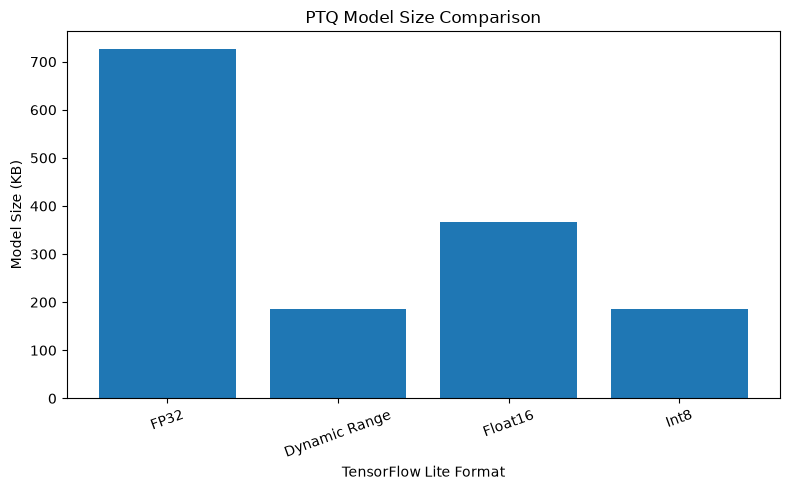

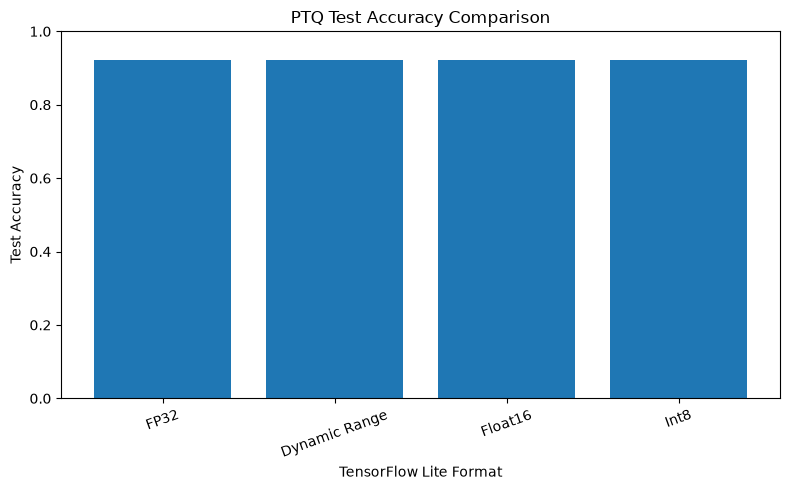

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    ptq_comparison_df["Format"],
    ptq_comparison_df["Model Size (KB)"]
)

plt.xlabel("TensorFlow Lite Format")
plt.ylabel("Model Size (KB)")
plt.title("PTQ Model Size Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.bar(
    ptq_comparison_df["Format"],
    ptq_comparison_df["Test Accuracy"]
)

plt.xlabel("TensorFlow Lite Format")
plt.ylabel("Test Accuracy")
plt.title("PTQ Test Accuracy Comparison")
plt.ylim(0.0, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


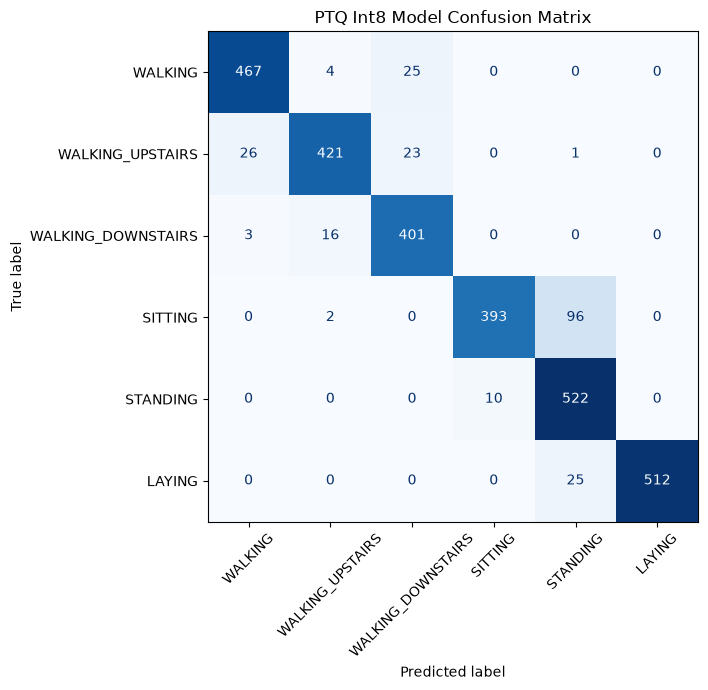

PTQ int8 classification report:
                    precision    recall  f1-score   support

           WALKING     0.9415    0.9415    0.9415       496
  WALKING_UPSTAIRS     0.9503    0.8938    0.9212       471
WALKING_DOWNSTAIRS     0.8931    0.9548    0.9229       420
           SITTING     0.9752    0.8004    0.8792       491
          STANDING     0.8106    0.9812    0.8878       532
            LAYING     1.0000    0.9534    0.9762       537

          accuracy                         0.9216      2947
         macro avg     0.9285    0.9209    0.9215      2947
      weighted avg     0.9287    0.9216    0.9218      2947



In [16]:
ptq_int8_confusion_matrix = confusion_matrix(
    y_test,
    ptq_int8_predictions,
    labels=np.arange(num_classes)
)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay(
    confusion_matrix=ptq_int8_confusion_matrix,
    display_labels=class_names
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title(
    "PTQ Int8 Model Confusion Matrix"
)

plt.tight_layout()
plt.show()

print("PTQ int8 classification report:")

print(classification_report(
    y_test,
    ptq_int8_predictions,
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=4,
    zero_division=0
))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [17]:
qat_model = (
    tfmot.quantization.keras
    .quantize_model(baseline_model)
)

qat_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.summary()

Model: "uci_har_baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)        

### Fine-Tune the QAT Model


In [18]:
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 2s 15ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 1s 12ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 1s 14ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 12ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [===

### Evaluate the QAT Keras Model


In [19]:
qat_test_loss, qat_keras_test_accuracy = (
    qat_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )
)

qat_keras_probabilities = qat_model.predict(
    X_test,
    verbose=0
)

qat_keras_predictions = np.argmax(
    qat_keras_probabilities,
    axis=1
)

print(
    f"QAT Keras test loss: "
    f"{qat_test_loss:.4f}"
)

print(
    f"QAT Keras test accuracy: "
    f"{qat_keras_test_accuracy:.4f}"
)

print("\nQAT Keras classification report:")

print(classification_report(
    y_test,
    qat_keras_predictions,
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=4,
    zero_division=0
))

QAT Keras test loss: 0.2461
QAT Keras test accuracy: 0.9321

QAT Keras classification report:
                    precision    recall  f1-score   support

           WALKING     0.9200    0.9738    0.9461       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.9447    0.9357    0.9402       420
           SITTING     0.9698    0.8493    0.9055       491
          STANDING     0.8425    0.9756    0.9042       532
            LAYING     1.0000    0.9516    0.9752       537

          accuracy                         0.9321      2947
         macro avg     0.9369    0.9310    0.9322      2947
      weighted avg     0.9363    0.9321    0.9323      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [20]:
qat_int8_tflite_model = (
    convert_to_tflite_int8(qat_model)
)

qat_int8_size_kb = save_binary_model(
    qat_int8_tflite_model,
    "qat_int8.tflite"
)

qat_int8_accuracy, qat_int8_predictions = (
    evaluate_tflite_model(
        qat_int8_tflite_model,
        X_test,
        y_test
    )
)

print(
    f"QAT int8 test accuracy: "
    f"{qat_int8_accuracy:.4f}"
)

print(
    f"QAT int8 model size: "
    f"{qat_int8_size_kb:.2f} KB"
)

INFO:tensorflow:Assets written to: /tmp/tmpdtkv6zg6/assets


INFO:tensorflow:Assets written to: /tmp/tmpdtkv6zg6/assets


QAT int8 test accuracy: 0.9318
QAT int8 model size: 185.93 KB


/home/rambo/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-14 18:17:52.992851: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 18:17:52.992907: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 18:17:52.993130: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpdtkv6zg6
2026-07-14 18:17:52.995775: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 18:17:52.995818: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpdtkv6zg6
2026-07-14 18:17:53.004343: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 18:17:53.055806: I tensorflow/cc/saved_model/loader

## 12. PTQ Int8 vs QAT Int8


In [21]:
int8_comparison_df = pd.DataFrame([
    {
        "Model": "PTQ Int8",
        "Test Accuracy": ptq_int8_accuracy,
        "Model Size (KB)": ptq_int8_size_kb
    },
    {
        "Model": "QAT Int8",
        "Test Accuracy": qat_int8_accuracy,
        "Model Size (KB)": qat_int8_size_kb
    }
])

int8_comparison_df.round({
    "Test Accuracy": 4,
    "Model Size (KB)": 2
})

,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.9216,185.51
1,QAT Int8,0.9318,185.93


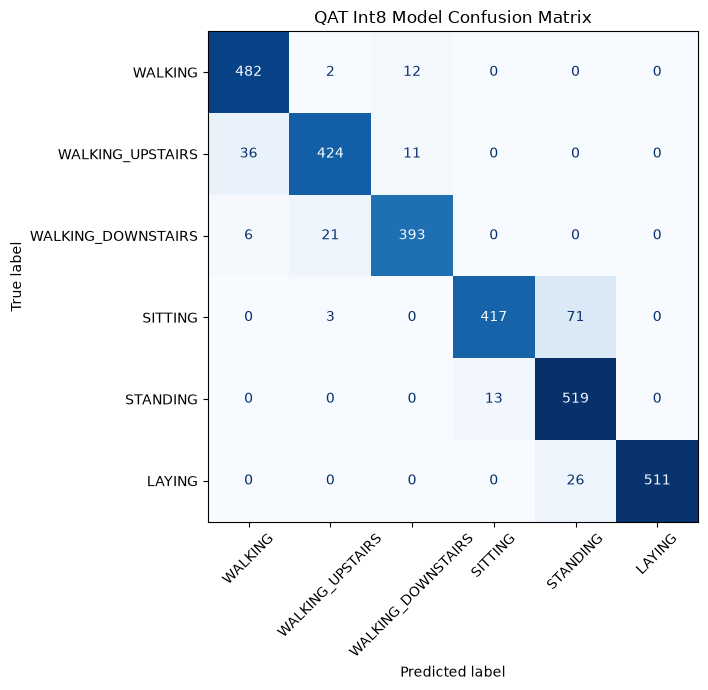

In [22]:
qat_int8_confusion_matrix = confusion_matrix(
    y_test,
    qat_int8_predictions,
    labels=np.arange(num_classes)
)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay(
    confusion_matrix=qat_int8_confusion_matrix,
    display_labels=class_names
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title(
    "QAT Int8 Model Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size? PTQ int8 produced the smallest model at approximately 185.51 KB
2. Which quantization method gave the best accuracy among the TensorFlow Lite models? The QAT int8 model achieved the highest TensorFlow Lite accuracy at approximately 93.18%.
3. Did QAT improve the final int8 model compared with PTQ int8? Yes. PTQ int8 achieved approximately 92.16% accuracy, while QAT int8 achieved approximately 93.18%. QAT improved accuracy by about 1.02 percentage points with only a very small increase in model size.
4. Why is this dataset a good fit for a DNN-based TinyML workflow? The UCI HAR dataset contains fixed length numerical sensor features and only six activity classes. This makes it suitable for a small fully connected neural network without requiring a large or computationally expensive architecture.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? I would choose the QAT int8 model because it provides the best accuracy while remaining much smaller than the FP32 and float16 models. It also uses integer operations, which are generally more suitable for tiny microcontrollers and can provide faster, more energy-efficient inference.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
